In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
# Load the ML-ready dataset
df = pd.read_csv('ml_ready_with_features.csv', sep=';')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
df.head()

Dataset shape: (9161, 19)

Column names:
['id', 'Title', 'Artists', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', '# of Nationality', 'Loudness_norm', 'best_rank', 'weeks_on_chart', 'peak_score', 'longevity_score', 'popularity_score', 'popularity_label']

First few rows:


,id,Title,Artists,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,# of Artist,# of Nationality,Loudness_norm,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score,popularity_label
0,000xQL6tZNLJzIrtIgxqSl,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,0.748,0.627,-6.029,0.064,0.131,0.0,0.524,Artist 1,Nationality 1,0.825120,40,118,80.5,100.0,80.25,Popular
1,003VDDA7J3Xb2ZFlNx7nIZ,YELL OH,"Trippie Redd, Young Thug",0.842,0.578,-6.050,0.138,0.004,0.0,0.190,Artist 1,Nationality 1,0.824511,108,2,46.5,10.0,27.25,Not Popular
2,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,0.353,0.755,-6.276,0.733,0.082,0.0,0.437,Artist 1,Nationality 1,0.817955,91,14,55.0,70.0,55.50,Not Popular
3,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,0.352,0.911,-5.230,0.075,0.001,0.0,0.236,Artist 1,Nationality 1,0.848296,73,560,64.0,100.0,72.00,Popular
4,00B7TZ0Xawar6NZ00JFomN,Best Life (feat. Chance The Rapper),Cardi B,0.620,0.625,-7.438,0.553,0.287,0.0,0.665,Artist 1,Nationality 1,0.784249,61,14,70.0,70.0,63.00,Not Popular


In [7]:
# Set pandas display options to show full output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Check for missing values
print("Missing values:")
print(df.isnull().sum())


# Basic statistics
print(f"\nFeature statistics:")
df.describe()

Missing values:
id                  0
Title               0
Artists             0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Valence             0
# of Artist         0
# of Nationality    0
Loudness_norm       0
best_rank           0
weeks_on_chart      0
peak_score          0
longevity_score     0
popularity_score    0
popularity_label    0
dtype: int64

Feature statistics:


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,Loudness_norm,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score
count,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.00000,9161.000000,9161.000000
mean,0.674146,0.636076,-6.465501,0.128299,0.234024,0.013770,0.486465,0.812458,87.258160,50.983626,56.87092,51.429975,49.007450
std,0.147904,0.170402,2.641113,0.117881,0.248563,0.082544,0.226281,0.076610,58.544799,120.342609,29.27240,41.295436,28.067511
min,0.073000,0.005000,-34.475000,0.022000,0.000000,0.000000,0.026000,0.000000,1.000000,1.000000,0.50000,5.000000,2.250000
25%,0.581000,0.532000,-7.638000,0.044000,0.040000,0.000000,0.310000,0.778448,35.000000,2.000000,33.00000,10.000000,23.000000
50%,0.691000,0.651000,-6.063000,0.076000,0.139000,0.000000,0.482000,0.824133,81.000000,8.000000,60.00000,40.000000,49.750000
75%,0.782000,0.761000,-4.731000,0.180000,0.351000,0.000000,0.660000,0.862770,135.000000,44.000000,83.00000,100.000000,75.750000
max,0.985000,0.996000,0.000000,0.966000,0.994000,0.956000,0.982000,1.000000,200.000000,2251.000000,100.00000,100.000000,90.000000


In [6]:
# Check label distribution - cleaner output
print(f"\n{'='*50}")
print("LABEL DISTRIBUTION")
print('='*50)

# Counts
print("\nCounts:")
for label, count in df['popularity_label'].value_counts().items():
    print(f"  {label:15s}: {count:,}")

# Percentages
print("\nPercentages:")
for label, pct in (df['popularity_label'].value_counts(normalize=True) * 100).items():
    print(f"  {label:15s}: {pct:.2f}%")

print(f"\nTotal songs: {len(df):,}")
print('='*50)


LABEL DISTRIBUTION

Counts:
  Not Popular    : 6,391
  Popular        : 2,770

Percentages:
  Not Popular    : 69.76%
  Popular        : 30.24%

Total songs: 9,161


In [25]:
# Create engineered features - Audio Interactions
df['dance_potential'] = df['Energy'] * df['Danceability']
df['feel_good_score'] = df['Valence'] * df['Energy']
df['chill_score'] = df['Acousticness'] * (1 - df['Energy'])
df['party_score'] = 0.4 * df['Energy'] + 0.4 * df['Danceability'] + 0.2 * df['Valence']

print("✓ Engineered features created successfully!")
print(f"\nNew features preview:")
print(df[['dance_potential', 'feel_good_score', 'chill_score', 'party_score']].describe())

✓ Engineered features created successfully!

New features preview:
       dance_potential  feel_good_score  chill_score  party_score
count      9161.000000      9161.000000  9161.000000  9161.000000
mean          0.432021         0.323782     0.107706     0.621382
std           0.146726         0.190431     0.161570     0.123604
min           0.001022         0.000518     0.000000     0.042200
25%           0.341044         0.172032     0.010669     0.551800
50%           0.443275         0.302286     0.041184     0.635600
75%           0.535806         0.455112     0.124683     0.708800
max           0.870610         0.939910     0.965294     0.928000


In [10]:
# Define feature columns (audio features only, exclude metadata and scores)
feature_columns = ['Danceability', 'Energy', 'Speechiness', 
                   'Acousticness', 'Instrumentalness', 'Valence', 'Loudness_norm']

# Separate features (X) and target (y)
X = df[feature_columns]
y = df['popularity_label']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures:")
print(X.columns.tolist())
print(f"\nTarget values: {y.unique()}")

Features shape: (9161, 7)
Target shape: (9161,)

Features:
['Danceability', 'Energy', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', 'Loudness_norm']

Target values: ['Popular' 'Not Popular']


In [11]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Keep same proportion of labels in train/test
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining label distribution:")
print(y_train.value_counts())
print(f"\nTest label distribution:")
print(y_test.value_counts())

Training set size: 7328
Test set size: 1833

Training label distribution:
popularity_label
Not Popular    5112
Popular        2216
Name: count, dtype: int64

Test label distribution:
popularity_label
Not Popular    1279
Popular         554
Name: count, dtype: int64


In [14]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"\nOriginal feature ranges:")
print(X_train.describe().loc[['min', 'max']])
print(f"\nScaled feature ranges:")
print(pd.DataFrame(X_train_scaled, columns=feature_columns).describe().loc[['min', 'max']])

Features scaled successfully!

Original feature ranges:
     Danceability  Energy  Speechiness  Acousticness  Instrumentalness  \
min         0.073   0.005        0.022         0.000             0.000   
max         0.985   0.996        0.920         0.992             0.956   

     Valence  Loudness_norm  
min    0.026       0.096157  
max    0.978       1.000000  

Scaled feature ranges:
     Danceability    Energy  Speechiness  Acousticness  Instrumentalness  \
min     -4.024200 -3.689566    -0.904513     -0.945057         -0.166564   
max      2.092135  2.111975     6.743964      3.033660         11.329625   

      Valence  Loudness_norm  
min -2.031278      -9.387526  
max  2.175967       2.454692  


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode labels to numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data with encoded labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nLabel encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} → {i}")
print(f"\nTraining label distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest label distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 7328
Test set size: 1833

Label encoding:
  Not Popular → 0
  Popular → 1

Training label distribution:
0    5112
1    2216
Name: count, dtype: int64

Test label distribution:
0    1279
1     554
Name: count, dtype: int64


,id,Title,Artists,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,# of Artist,# of Nationality,Loudness_norm,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score,popularity_label
0,000xQL6tZNLJzIrtIgxqSl,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,0.748,0.627,-6.029,0.064,0.131,0.0,0.524,Artist 1,Nationality 1,0.825120,40,118,80.5,100.0,80.25,Popular
1,003VDDA7J3Xb2ZFlNx7nIZ,YELL OH,"Trippie Redd, Young Thug",0.842,0.578,-6.050,0.138,0.004,0.0,0.190,Artist 1,Nationality 1,0.824511,108,2,46.5,10.0,27.25,Not Popular
2,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,0.353,0.755,-6.276,0.733,0.082,0.0,0.437,Artist 1,Nationality 1,0.817955,91,14,55.0,70.0,55.50,Not Popular
3,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,0.352,0.911,-5.230,0.075,0.001,0.0,0.236,Artist 1,Nationality 1,0.848296,73,560,64.0,100.0,72.00,Popular
4,00B7TZ0Xawar6NZ00JFomN,Best Life (feat. Chance The Rapper),Cardi B,0.620,0.625,-7.438,0.553,0.287,0.0,0.665,Artist 1,Nationality 1,0.784249,61,14,70.0,70.0,63.00,Not Popular


In [21]:
# Dictionary to store models and their results
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train==1])), 
                             random_state=42, eval_metric='logloss'),
    'SVM': SVC(class_weight='balanced', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results = {}

print("Training models...\n")
print("="*70)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics (use pos_label=1 for encoded 'Popular')
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")

print("\n" + "="*70)
print("All models trained successfully!")

Training models...


Training Logistic Regression...
  ✓ Accuracy: 0.5417
  ✓ F1-Score: 0.4430

Training Random Forest...
  ✓ Accuracy: 0.7005
  ✓ F1-Score: 0.2805

Training XGBoost...
  ✓ Accuracy: 0.6192
  ✓ F1-Score: 0.4193

Training SVM...
  ✓ Accuracy: 0.5292
  ✓ F1-Score: 0.4528

Training KNN...
  ✓ Accuracy: 0.6536
  ✓ F1-Score: 0.2952

Training Naive Bayes...
  ✓ Accuracy: 0.5439
  ✓ F1-Score: 0.4258

All models trained successfully!



MODEL PERFORMANCE COMPARISON
              Model  Accuracy  F1-Score
                SVM  0.529187  0.452758
Logistic Regression  0.541735  0.442971
        Naive Bayes  0.543917  0.425824
            XGBoost  0.619203  0.419301
                KNN  0.653573  0.295228
      Random Forest  0.700491  0.280472


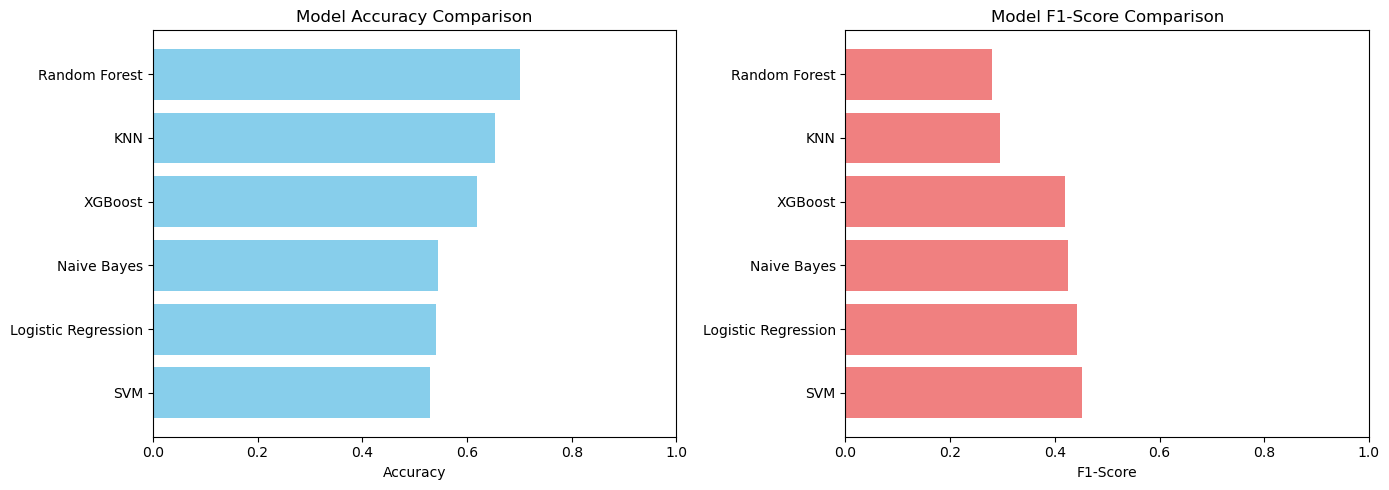

In [22]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].barh(comparison_df['Model'], comparison_df['Accuracy'], color='skyblue')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlim([0, 1])

# F1-Score comparison
axes[1].barh(comparison_df['Model'], comparison_df['F1-Score'], color='lightcoral')
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Model F1-Score Comparison')
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.show()


DETAILED EVALUATION: SVM

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.76      0.48      0.59      1279
     Popular       0.35      0.64      0.45       554

    accuracy                           0.53      1833
   macro avg       0.55      0.56      0.52      1833
weighted avg       0.63      0.53      0.55      1833



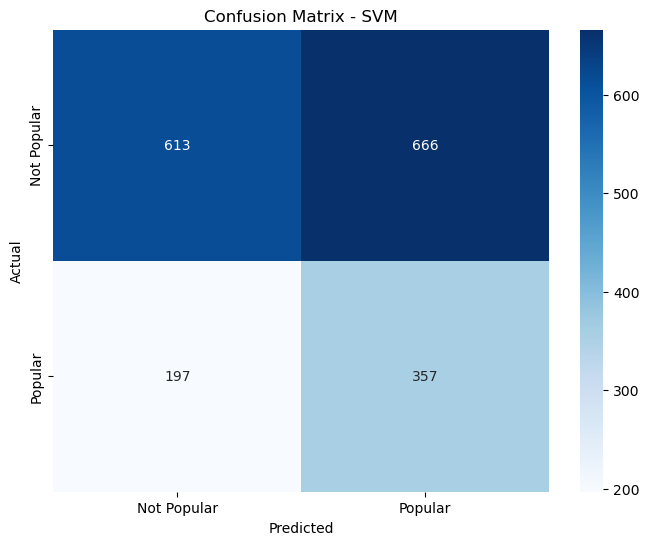

In [24]:
# Get best model based on F1-score
best_model_name = comparison_df.iloc[0]['Model']
best_predictions = results[best_model_name]['predictions']

print(f"\n{'='*70}")
print(f"DETAILED EVALUATION: {best_model_name}")
print('='*70)

# Classification report (with target names for better readability)
print("\nClassification Report:")
print(classification_report(y_test, best_predictions, 
                           target_names=['Not Popular', 'Popular']))

# Confusion matrix (use numeric labels)
cm = confusion_matrix(y_test, best_predictions, labels=[0, 1])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()